# BeetleCast 04 — LULC forest-control ablation

This notebook strengthens the experiment by asking the harder question:

> Can BeetleCast distinguish mapped bark-beetle damage from apparently healthy forest?

It compares:

1. Temporal-AEF model on a stable-forest subset
2. Temporal-AEF model + historical LULC features

Leakage-safe LULC history:

- 2022 labels use LULC 2018–2021
- 2023 labels use LULC 2018–2022
- LULC 2023–2025 is ignored during retrospective validation

Outputs are written to `outputs/lulc/`.


In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import rasterio
import rioxarray

from affine import Affine
from pyproj import CRS
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio.transform import from_origin

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
PATCH_PIXELS = 5
TEST_FRACTION = 0.25
MIN_LULC_YEAR = 2018

# Stable-forest definition.
LATEST_FOREST_MIN = 0.50
FOREST_PERSISTENCE_MIN = 0.80

cwd = Path.cwd()
if (cwd / "hackathon_data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "hackathon_data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find hackathon_data/. Launch Jupyter from project_root."
    )

DATA_ROOT = PROJECT_ROOT / "hackathon_data"
RAW_ROOT = DATA_ROOT / "raw"
TEMPORAL_AEF_ROOT = PROJECT_ROOT / "outputs" / "temporal_aef"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "lulc"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


PROJECT_ROOT: /Users/hemat/Desktop/hackathon-demo
OUTPUT_ROOT: /Users/hemat/Desktop/hackathon-demo/outputs/lulc


## 1. Load the temporal-AEF training table

In [2]:
training_path = (
    TEMPORAL_AEF_ROOT
    / "beetlecast_temporal_aef_training_table.csv"
)

assert training_path.exists(), (
    "Missing outputs/temporal_aef/beetlecast_temporal_aef_training_table.csv. "
    "Run notebook 03 first."
)

training = pd.read_csv(training_path)

baseline_features = [
    "ndvi_recent",
    "ndre_recent",
    "nbr_recent",
    "ndvi_prior",
    "ndre_prior",
    "nbr_prior",
    "ndvi_change",
    "ndre_change",
    "nbr_change",
    "ndvi_std",
    "ndre_std",
    "valid_fraction",
]

temporal_aef_features = [
    c for c in training.columns
    if c.startswith("aef_")
]

assert temporal_aef_features, (
    "No temporal AEF columns found in the training table."
)

required = {
    "label_year",
    "patch_row",
    "patch_col",
    "target",
    "spatial_block",
} | set(baseline_features) | set(temporal_aef_features)

missing = required - set(training.columns)
assert not missing, f"Missing columns: {missing}"

print("Rows:", len(training))
print("Temporal AEF features:", len(temporal_aef_features))
print(training.groupby(["label_year", "target"]).size())


Rows: 19944
Temporal AEF features: 320
label_year  target
2022        0         7602
            1         2534
2023        0         7356
            1         2452
dtype: int64


## 2. Find LULC rasters and class definitions

In [3]:
lulc_tifs = [
    p for p in RAW_ROOT.rglob("*.tif")
    if "lulc" in str(p).lower()
    or "landcover" in str(p).lower()
    or "land_cover" in str(p).lower()
]

assert lulc_tifs, (
    "No LULC TIFFs found. Put the ESRI annual files under "
    "hackathon_data/raw/esri_lulc/."
)

def infer_year(path):
    match = re.search(r"(20(?:1[7-9]|2[0-5]))", path.name)
    return int(match.group(1)) if match else None

lulc_by_year = {}
for path in lulc_tifs:
    year = infer_year(path)
    if year is not None:
        lulc_by_year.setdefault(year, []).append(path)

print("LULC years found:", sorted(lulc_by_year))

needed_years = set(range(2018, 2023))
missing_years = sorted(needed_years - set(lulc_by_year))
assert not missing_years, (
    f"Missing LULC years required for this experiment: {missing_years}"
)

selected_lulc = {
    year: sorted(lulc_by_year[year])[0]
    for year in sorted(lulc_by_year)
    if 2018 <= year <= 2022
}

for year, path in selected_lulc.items():
    print(year, "->", path)

class_jsons = list(RAW_ROOT.rglob("*lulc*class*.json"))
print("Class JSON candidates:", class_jsons)


LULC years found: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
2018 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/esri_lulc/lulc_F3_Germany_BarkBeetle_2018.tif
2019 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/esri_lulc/lulc_F3_Germany_BarkBeetle_2019.tif
2020 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/esri_lulc/lulc_F3_Germany_BarkBeetle_2020.tif
2021 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/esri_lulc/lulc_F3_Germany_BarkBeetle_2021.tif
2022 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/esri_lulc/lulc_F3_Germany_BarkBeetle_2022.tif
Class JSON candidates: []


## 3. Detect the forest class code

The notebook searches the class JSON for labels containing `tree` or `forest`.  
If it cannot infer the class automatically, it falls back to ESRI's common `Trees = 2` code and prints a warning.


In [4]:
def collect_code_name_pairs(obj):
    pairs = []

    if isinstance(obj, dict):
        # Direct mappings such as {"2": "Trees"}.
        for key, value in obj.items():
            if isinstance(value, str):
                try:
                    code = int(key)
                    pairs.append((code, value))
                except Exception:
                    pass

            if isinstance(value, dict):
                code = (
                    value.get("value")
                    or value.get("code")
                    or value.get("id")
                    or value.get("class_id")
                )
                name = (
                    value.get("name")
                    or value.get("label")
                    or value.get("class_name")
                    or value.get("description")
                )
                if code is not None and name is not None:
                    try:
                        pairs.append((int(code), str(name)))
                    except Exception:
                        pass

            pairs.extend(collect_code_name_pairs(value))

    elif isinstance(obj, list):
        for item in obj:
            pairs.extend(collect_code_name_pairs(item))

    return pairs

code_name_pairs = []

for path in class_jsons:
    try:
        with open(path, "r") as handle:
            code_name_pairs.extend(
                collect_code_name_pairs(json.load(handle))
            )
    except Exception as exc:
        print("Could not parse", path, ":", exc)

# Deduplicate.
code_name_pairs = sorted(set(code_name_pairs))
print("Detected class definitions:")
for code, name in code_name_pairs:
    print(code, "->", name)

forest_codes = sorted({
    code
    for code, name in code_name_pairs
    if "tree" in name.lower() or "forest" in name.lower()
})

if not forest_codes:
    forest_codes = [2]
    print(
        "\nWARNING: Forest class was not found in the JSON. "
        "Falling back to class code 2 (Trees). Verify this against the palette."
    )

print("\nForest class code(s):", forest_codes)


Detected class definitions:


Forest class code(s): [2]


## 4. Reconstruct the Sentinel-2 grid

In [5]:
zarr_paths = list(RAW_ROOT.rglob("cube.zarr"))
f3_zarr = [
    p for p in zarr_paths
    if "f3" in str(p).lower()
    or "bark" in str(p).lower()
    or "germany" in str(p).lower()
]

assert f3_zarr or zarr_paths, "No Sentinel-2 cube found"
CUBE_PATH = (f3_zarr or zarr_paths)[0]

ds = xr.open_zarr(CUBE_PATH, chunks="auto")

if float(ds.y.values[0]) < float(ds.y.values[-1]):
    ds = ds.sortby("y", ascending=False)

x = np.asarray(ds.x.values)
y = np.asarray(ds.y.values)

dx = float(abs(x[1] - x[0]))
dy = float(abs(y[1] - y[0]))

left = float(x.min() - dx / 2)
top = float(y.max() + dy / 2)

base_transform = from_origin(left, top, dx, dy)
patch_transform = base_transform * Affine.scale(PATCH_PIXELS, PATCH_PIXELS)

base_height = ds.sizes["y"]
base_width = ds.sizes["x"]
patch_height = base_height // PATCH_PIXELS
patch_width = base_width // PATCH_PIXELS

def infer_cube_crs(dataset):
    try:
        if dataset.rio.crs is not None:
            return CRS.from_user_input(dataset.rio.crs)
    except Exception:
        pass

    if "spatial_ref" in dataset:
        attrs = dataset["spatial_ref"].attrs
        for key in ("crs_wkt", "spatial_ref", "wkt"):
            value = attrs.get(key)
            if value:
                return CRS.from_user_input(value)

    raise ValueError("Could not infer Sentinel-2 CRS")

grid_crs = infer_cube_crs(ds)

print("Base grid:", base_height, "x", base_width)
print("Patch grid:", patch_height, "x", patch_width)
print("CRS:", grid_crs)


Base grid: 1262 x 1065
Patch grid: 252 x 213
CRS: PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]


## 5. Align annual LULC and calculate forest fraction

Categorical LULC is resampled with nearest-neighbour interpolation.  
Forest fraction is then calculated inside each 50 m modelling patch.


In [6]:
def read_lulc_forest_fraction(path):
    with rasterio.open(path) as src:
        print(
            f"{path.name}: bands={src.count}, CRS={src.crs}, "
            f"shape={src.height}x{src.width}"
        )

        with WarpedVRT(
            src,
            crs=grid_crs,
            transform=base_transform,
            width=base_width,
            height=base_height,
            resampling=Resampling.nearest,
            nodata=0,
        ) as vrt:
            data = vrt.read(1, masked=True)

    values = data.filled(0)
    forest = np.isin(values, forest_codes).astype("float32")

    trimmed = forest[
        : patch_height * PATCH_PIXELS,
        : patch_width * PATCH_PIXELS,
    ]

    fraction = trimmed.reshape(
        patch_height,
        PATCH_PIXELS,
        patch_width,
        PATCH_PIXELS,
    ).mean(axis=(1, 3))

    return fraction

forest_fraction_by_year = {
    year: read_lulc_forest_fraction(path)
    for year, path in selected_lulc.items()
}

for year, fraction in forest_fraction_by_year.items():
    print(
        year,
        "mean forest fraction:",
        float(np.nanmean(fraction)),
    )


lulc_F3_Germany_BarkBeetle_2018.tif: bands=1, CRS=EPSG:4326, shape=1271x1643
lulc_F3_Germany_BarkBeetle_2019.tif: bands=1, CRS=EPSG:4326, shape=1271x1643
lulc_F3_Germany_BarkBeetle_2020.tif: bands=1, CRS=EPSG:4326, shape=1271x1643
lulc_F3_Germany_BarkBeetle_2021.tif: bands=1, CRS=EPSG:4326, shape=1271x1643
lulc_F3_Germany_BarkBeetle_2022.tif: bands=1, CRS=EPSG:4326, shape=1271x1643
2018 mean forest fraction: 0.6733996272087097
2019 mean forest fraction: 0.6676592826843262
2020 mean forest fraction: 0.65970778465271
2021 mean forest fraction: 0.5753968358039856
2022 mean forest fraction: 0.6345070004463196


## 6. Attach historical LULC features

In [7]:
lulc_rows = []

for row in training.itertuples(index=False):
    label_year = int(row.label_year)
    latest_year = label_year - 1

    valid_years = [
        year for year in sorted(forest_fraction_by_year)
        if MIN_LULC_YEAR <= year <= latest_year
    ]

    if len(valid_years) < 2:
        raise ValueError(
            f"Not enough pre-label LULC history for {label_year}"
        )

    r = int(row.patch_row)
    c = int(row.patch_col)

    history = np.array([
        forest_fraction_by_year[year][r, c]
        for year in valid_years
    ], dtype="float32")

    binary_forest = history >= 0.50

    lulc_rows.append({
        "latest_forest_fraction": float(history[-1]),
        "forest_persistence": float(np.mean(history)),
        "minimum_forest_fraction": float(np.min(history)),
        "forest_fraction_change": float(history[-1] - history[0]),
        "forest_state_change_count": int(
            np.count_nonzero(binary_forest[1:] != binary_forest[:-1])
        ),
        "stable_forest": bool(
            history[-1] >= LATEST_FOREST_MIN
            and np.mean(history) >= FOREST_PERSISTENCE_MIN
        ),
    })

lulc_features = pd.DataFrame(lulc_rows)

combined = pd.concat(
    [training.reset_index(drop=True), lulc_features],
    axis=1,
)

lulc_feature_columns = [
    "latest_forest_fraction",
    "forest_persistence",
    "minimum_forest_fraction",
    "forest_fraction_change",
    "forest_state_change_count",
]

combined_path = OUTPUT_ROOT / "beetlecast_training_table_with_lulc.csv"
combined.to_csv(combined_path, index=False)

print("Combined rows:", len(combined))
print("Stable-forest rows:", int(combined["stable_forest"].sum()))
print(
    combined.groupby(["label_year", "target", "stable_forest"])
    .size()
)

print("Saved:", combined_path)


Combined rows: 19944
Stable-forest rows: 16092
label_year  target  stable_forest
2022        0       False            1778
                    True             5824
            1       False             431
                    True             2103
2023        0       False            1217
                    True             6139
            1       False             426
                    True             2026
dtype: int64
Saved: /Users/hemat/Desktop/hackathon-demo/outputs/lulc/beetlecast_training_table_with_lulc.csv


## 7. Create a common stable-forest blocked split

Both models are evaluated on exactly the same stable-forest rows and spatial blocks.


In [8]:
model_base_features = baseline_features + temporal_aef_features

stable = combined[
    combined["stable_forest"]
].dropna(
    subset=model_base_features
    + lulc_feature_columns
    + ["target", "spatial_block"]
).copy()

assert stable["target"].nunique() == 2, (
    "The stable-forest subset does not contain both classes. "
    "Inspect the class code and thresholds."
)

print("Stable-forest rows:", len(stable))
print("Positive rate:", stable["target"].mean())
print(stable.groupby(["label_year", "target"]).size())

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_FRACTION,
    random_state=RANDOM_STATE,
)

train_idx, test_idx = next(
    splitter.split(
        stable,
        stable["target"],
        stable["spatial_block"],
    )
)

train = stable.iloc[train_idx]
test = stable.iloc[test_idx]

print("Train rows:", len(train))
print("Test rows:", len(test))
print("Train blocks:", train["spatial_block"].nunique())
print("Test blocks:", test["spatial_block"].nunique())


Stable-forest rows: 16092
Positive rate: 0.25658712403678846
label_year  target
2022        0         5824
            1         2103
2023        0         6139
            1         2026
dtype: int64
Train rows: 12107
Test rows: 3985
Train blocks: 463
Test blocks: 155


## 8. Compare temporal AEF against temporal AEF + LULC

In [9]:
def top_fraction_capture(y_true, risk, fraction=0.10):
    y_true = np.asarray(y_true).astype(int)
    risk = np.asarray(risk)

    n_select = max(1, int(np.ceil(len(risk) * fraction)))
    selected = np.argsort(risk)[-n_select:]

    total_positive = y_true.sum()
    if total_positive == 0:
        return np.nan

    return y_true[selected].sum() / total_positive

def fit_and_score(feature_columns, name):
    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=350,
        max_leaf_nodes=31,
        min_samples_leaf=25,
        l2_regularization=2.0,
        random_state=RANDOM_STATE,
    )

    weights = compute_sample_weight(
        class_weight="balanced",
        y=train["target"].astype(int),
    )

    model.fit(
        train[feature_columns],
        train["target"].astype(int),
        sample_weight=weights,
    )

    risk = model.predict_proba(test[feature_columns])[:, 1]
    y_true = test["target"].to_numpy().astype(int)

    metrics = {
        "model": name,
        "feature_count": len(feature_columns),
        "pr_auc": average_precision_score(y_true, risk),
        "roc_auc": roc_auc_score(y_true, risk),
        "top_10_percent_capture": top_fraction_capture(
            y_true, risk, 0.10
        ),
    }

    return model, risk, metrics

aef_model, aef_risk, aef_metrics = fit_and_score(
    model_base_features,
    "Temporal AEF on stable forest",
)

lulc_model, lulc_risk, lulc_metrics = fit_and_score(
    model_base_features + lulc_feature_columns,
    "Temporal AEF + LULC",
)

metrics_df = pd.DataFrame([aef_metrics, lulc_metrics])

metrics_path = OUTPUT_ROOT / "beetlecast_lulc_comparison.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print("Saved:", metrics_path)


,model,feature_count,pr_auc,roc_auc,top_10_percent_capture
0,Temporal AEF on stable forest,332,0.881066,0.952258,0.395897
1,Temporal AEF + LULC,337,0.879031,0.951702,0.393846


Saved: /Users/hemat/Desktop/hackathon-demo/outputs/lulc/beetlecast_lulc_comparison.csv


## 9. Plot and decide

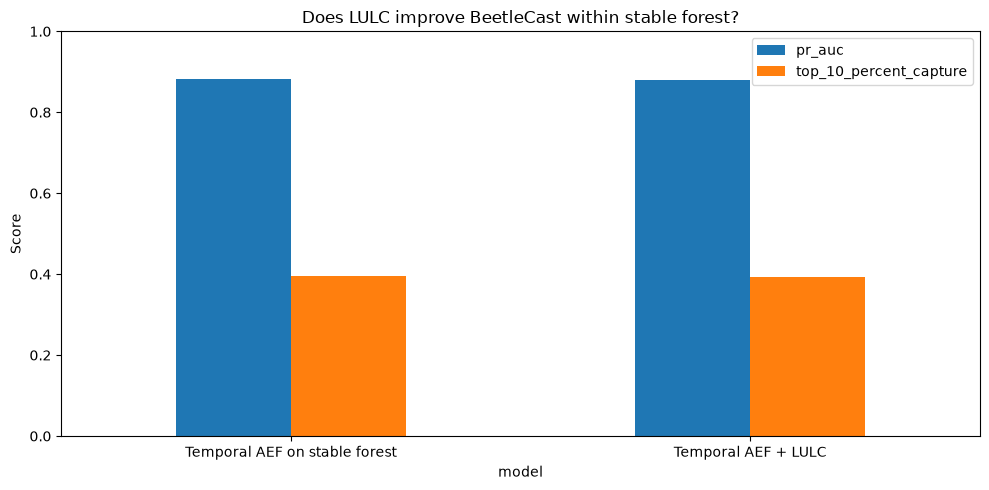

LULC CONTROL COMPLETE
---------------------
Temporal AEF stable-forest PR-AUC: 0.881
Temporal AEF + LULC PR-AUC: 0.879
Temporal AEF stable-forest top-10% capture: 39.6%
Temporal AEF + LULC top-10% capture: 39.4%

Decision: keep the stable-forest mask for credibility, but do not force LULC features into the classifier.

Saved: /Users/hemat/Desktop/hackathon-demo/outputs/lulc/beetlecast_lulc_comparison.png


In [10]:
plot_df = metrics_df.set_index("model")[
    ["pr_auc", "top_10_percent_capture"]
]

ax = plot_df.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Does LULC improve BeetleCast within stable forest?")
plt.tight_layout()

plot_path = OUTPUT_ROOT / "beetlecast_lulc_comparison.png"
plt.savefig(plot_path, dpi=220, bbox_inches="tight")
plt.show()

aef_row = metrics_df[
    metrics_df["model"] == "Temporal AEF on stable forest"
].iloc[0]

lulc_row = metrics_df[
    metrics_df["model"] == "Temporal AEF + LULC"
].iloc[0]

print("LULC CONTROL COMPLETE")
print("---------------------")
print(
    f"Temporal AEF stable-forest PR-AUC: "
    f"{aef_row.pr_auc:.3f}"
)
print(
    f"Temporal AEF + LULC PR-AUC: "
    f"{lulc_row.pr_auc:.3f}"
)
print(
    f"Temporal AEF stable-forest top-10% capture: "
    f"{aef_row.top_10_percent_capture:.1%}"
)
print(
    f"Temporal AEF + LULC top-10% capture: "
    f"{lulc_row.top_10_percent_capture:.1%}"
)

if (
    lulc_row.pr_auc > aef_row.pr_auc
    or lulc_row.top_10_percent_capture
    > aef_row.top_10_percent_capture
):
    print(
        "\nDecision: keep LULC features and the stable-forest mask."
    )
else:
    print(
        "\nDecision: keep the stable-forest mask for credibility, "
        "but do not force LULC features into the classifier."
    )

print("\nSaved:", plot_path)
